In [1]:
import numpy as np
from tensorflow.keras.optimizers import Adam
from keras.layers import Activation, Dropout, Convolution2D, GlobalAveragePooling2D
from keras.models import Sequential
import tensorflow as tf
import tensorflow.keras.applications.mobilenet
import os
import PIL
import cv2
import keras
import matplotlib.pyplot as plt
from keras import layers
from keras import Model
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau


def preprocess(new_path):
    imgpath=PIL.Image.open(new_path)
    imgpath=imgpath.convert('RGB')
    img = np.asarray(imgpath)
    img = cv2.resize(img, (331,331))
    img=img/255.
    return img
IMG_SAVE_PATH_Test="2.jpeg"
traindata=preprocess(IMG_SAVE_PATH_Test)

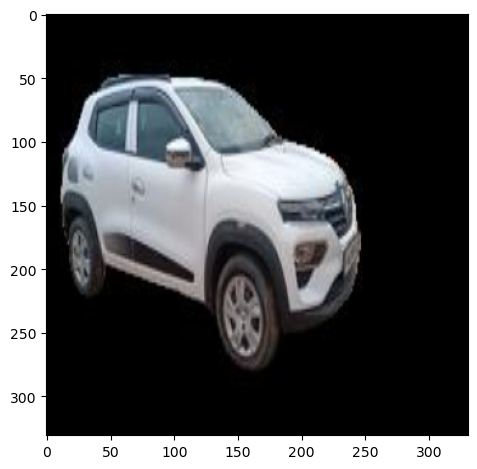

In [2]:
plt.imshow(traindata) 
plt.tight_layout()
plt.show()


In [3]:
model = tf.keras.models.load_model('model.keras')
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 331, 331, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_209 (Conv2D)           │ (None, 165, 165, 32)      │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_203       │ (None, 165, 165, 32)      │              96 │ conv2d_209[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_209 (Activation)   │ (None, 165, 165, 32)      │               0 │ batch_normalization_203[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_210 (Conv2D)           │ (None, 163, 163, 32)      │           9,216 │ activation_209[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_204       │ (None, 163, 163, 32)      │              96 │ conv2d_210[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_210 (Activation)   │ (None, 163, 163, 32)      │               0 │ batch_normalization_204[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_211 (Conv2D)           │ (None, 163, 163, 64)      │          18,432 │ activation_210[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_205       │ (None, 163, 163, 64)      │             192 │ conv2d_211[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_211 (Activation)   │ (None, 163, 163, 64)      │               0 │ batch_normalization_205[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_10              │ (None, 81, 81, 64)        │               0 │ activation_211[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_212 (Conv2D)           │ (None, 81, 81, 80)        │           5,120 │ max_pooling2d_10[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_206       │ (None, 81, 81, 80)        │             240 │ conv2d_212[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_212 (Activation)   │ (None, 81, 81, 80)        │               0 │ batch_normalization_206[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_213 (Conv2D)           │ (None, 79, 79, 192)       │         138,24

 Total params: 395,543,322 (1.47 GB)

 Trainable params: 113,735,528 (433.87 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

 Optimizer params: 227,471,058 (867.73 MB)

In [4]:

xtest=[traindata]
xtest=np.array(xtest)


In [5]:
xtest.shape

(1, 331, 331, 3)

In [6]:
Y_pred = model.predict([xtest,xtest])


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [7]:
# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_pred,axis = 1) 

rear_right - 320


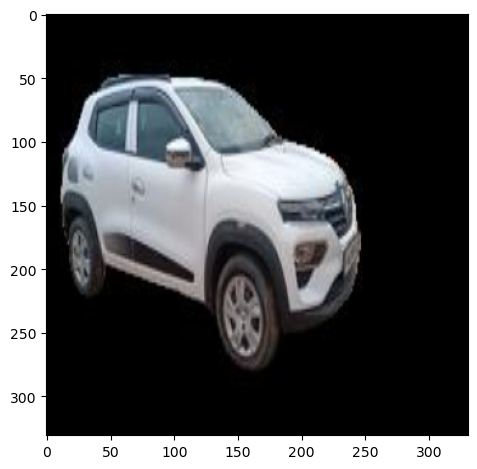

In [8]:
label= {'0': 0, '130': 1, '180': 2, '230': 3, '270': 4, '320': 5, '40': 6, '90': 7}
angle_mapping = {
    "right": 0,
    "front_left": 130,
    "left": 180,
    "rear_left": 230,
    "rear": 270,
    "rear_right": 320,
    "front_right": 40,
    "front": 90
}
angle_to_name = {v: k for k, v in angle_mapping.items()}
index_to_angle = {v: k for k, v in label.items()}

# Example: get value from prediction
pred_index = Y_pred_classes[0]
angle_value = int(index_to_angle[pred_index])
print(angle_to_name[angle_value] +" - " + str(angle_value) )
plt.imshow(traindata) 
plt.tight_layout()
plt.show()
